In [49]:
# import nbformat
# from google.colab import files

# nb_path = "/content/drive/MyDrive/Colab Notebooks/MS4_YOLO_combined_original_plus_augmented_fft_cp.ipynb"   # change to your notebook name

# nb = nbformat.read(nb_path, as_version=4)

# # 🔥 Remove widget metadata ONLY
# if "widgets" in nb["metadata"]:
#     del nb["metadata"]["widgets"]

# nbformat.write(nb, nb_path)

# print("✅ Cleaned notebook (outputs preserved)")

# files.download(nb_path)

✅ Cleaned notebook (outputs preserved)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# YOLO Sweep Winner: Final Retrain

**Configuration source:** W&B Bayesian sweep `zzovt4eb`, winning run `volcanic-sweep-2`.

Sweep mAP50 = 0.6697 (in 20 epochs). This notebook retrains the same hyperparameter combination for 50 epochs to push the final number higher.

**Winning hyperparameters:**
- `lr0=0.000173`, `weight_decay=7.2e-5`
- `box=12`, `cls=0.515`, `dfl=1.29` (loss weights)
- `mosaic=0.325`, `copy_paste=0.0086`, `close_mosaic=29` (augmentation)
- `optimizer=AdamW`, `imgsz=1024`, `batch=8`, `seed=42`

Pulled from the leaderboard at https://wandb.ai/rpatel9/hair-follicle-density-estimation-209b-MS4_sweep/sweeps/zzovt4eb

In [1]:
# Install dependencies (no-op if already installed)
import subprocess, sys
for pkg in ['ultralytics', 'albumentations', 'opencv-python', 'scipy', 'scikit-learn', 'tqdm']:
    try:
        __import__(pkg.replace('-', '_').split('[')[0])
    except ImportError:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.2 MB/s eta 0:00:00


In [2]:
import os
import shutil
import random
import yaml
import json
import xml.etree.ElementTree as ET
from dataclasses import dataclass, replace
from typing import List, Dict, Any, Optional, Tuple
from collections import Counter
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from tqdm.auto import tqdm

from ultralytics import YOLO
from torchvision.ops import box_iou
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
# Mount Google Drive (Colab only) or use local data on Lambda/Mac
import os
IS_COLAB = os.path.exists('/content') and 'COLAB_GPU' in os.environ

if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    # Copy data from Drive to runtime
    if not os.path.exists('/content/data/Images'):
        os.system('cp -r /content/drive/MyDrive/data /content/')
else:
    print(f'Not in Colab — using local data at {os.path.expanduser("~/hair-follicle-density-estimation-209b/data")}')


Mounted at /content/drive


##  Configuration

In [26]:
from dataclasses import dataclass, replace, field
import os

def _default_drive_dir():
    if os.path.exists("/content/drive/MyDrive"):
        return "/content/drive/MyDrive/yolo_follicle_sweep_winner"
    expanded = os.path.expanduser("~/hair-follicle-density-estimation-209b/MS4/checkpoints/yolo_sweep_winner_50ep")
    if os.path.exists(os.path.expanduser("~/hair-follicle-density-estimation-209b")):
        return expanded
    return "MS4/checkpoints/yolo_sweep_winner_50ep"


def _default_data_paths():
    """Detect repo and return image / annotation / split directories."""
    candidates = [
        "/content/data",  # Colab convention
        os.path.expanduser("~/hair-follicle-density-estimation-209b/data"),  # Lambda
        "data",  # local cwd
        "../data",  # relative
    ]
    for base in candidates:
        if os.path.exists(os.path.join(base, "Images")):
            return base
    return "/content/data"


_DATA_BASE = _default_data_paths()
_DRIVE_DIR = _default_drive_dir()
_YOLO_ROOT = "/tmp/yolo_follicle_dataset_sweep_winner" if not os.path.exists("/content") else "/content/yolo_follicle_dataset_sweep_winner"


@dataclass
class Config:
    # Original Pascal VOC dataset paths (auto-detected: Colab vs Lambda vs local)
    image_dir: str = field(default_factory=lambda: os.path.join(_DATA_BASE, "Images"))
    annot_dir: str = field(default_factory=lambda: os.path.join(_DATA_BASE, "Annotations"))
    split_dir: str = field(default_factory=lambda: os.path.join(_DATA_BASE, "ImageSets", "Main"))

    # YOLO-format dataset cache path (built once per environment)
    yolo_root: str = field(default_factory=lambda: _YOLO_ROOT)

    # Output folder for trained model + checkpoints (auto-detected per environment)
    drive_dir: str = field(default_factory=lambda: _DRIVE_DIR)
    run_name: str = "yolo_sweep_winner_50ep"

    # YOLO model
    pretrained_model_name: str = "yolo11m.pt"

    # Classes: 0 premium, 1 single, 2 undersize, 3 abnormal
    class_names: Optional[List[str]] = None

    # Training / validation
    image_size: int = 1024
    epochs: int = 50  # bumped from 20-epoch sweep for final retrain
    batch: int = 8
    workers: int = 2
    seed: int = 42
    patience: int = 25

    # Correct mAP validation setting
    map_conf_threshold: float = 0.001   # keep nearly all predictions for mAP PR curve
    val_iou_threshold: float = 0.70     # NMS IoU threshold during validation/prediction
    max_det: int = 1000                 # safer for dense follicle images

    # Manual copy-paste augmentation settings (NOT used in sweep-winner; kept for compatibility)
    use_light_manual_balancer: bool = False
    balance_target_classes: tuple = (2, 3)

    # Build the YOLO-format dataset from VOC (skip if already built)
    rebuild_dataset: bool = True

    def __post_init__(self):
        if self.class_names is None:
            self.class_names = ["premium", "single", "undersize", "abnormal"]


common_cfg = Config()
print("Resolved paths:")
print(f"  image_dir: {common_cfg.image_dir}")
print(f"  annot_dir: {common_cfg.annot_dir}")
print(f"  split_dir: {common_cfg.split_dir}")
print(f"  yolo_root: {common_cfg.yolo_root}")
print(f"  drive_dir (checkpoints): {common_cfg.drive_dir}")
print(f"  run_name: {common_cfg.run_name}")

# Module-level class mappings (used by parse_voc_xml and friends)
CLASS_NAMES = common_cfg.class_names
label2id = {name: i for i, name in enumerate(CLASS_NAMES)}
id2label = {i: name for i, name in enumerate(CLASS_NAMES)}
print(f"label2id: {label2id}")


{'premium': 0, 'single': 1, 'undersize': 2, 'abnormal': 3}


## Train/validation split

In [5]:
def read_split_txt(path: str) -> List[str]:
    with open(path) as f:
        return [line.strip() for line in f.readlines() if line.strip()]

train_files = read_split_txt(os.path.join(common_cfg.split_dir, "train.txt"))
val_files = read_split_txt(os.path.join(common_cfg.split_dir, "val.txt"))

print("train:", len(train_files))
print("val:", len(val_files))
print("example train file stem:", train_files[0] if train_files else None)


train: 992
val: 330
example train file stem: 220106_A207_2


## VOC parsing, YOLO box utilities, YAML creation, and sanity checks

In [6]:
def find_image_path(image_dir: str, stem: str) -> Optional[str]:
    for ext in [".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"]:
        p = os.path.join(image_dir, stem + ext)
        if os.path.exists(p):
            return p
    return None


def clip_box_xyxy(box, width, height):
    x1, y1, x2, y2 = box
    x1 = max(0.0, min(float(x1), width - 1))
    y1 = max(0.0, min(float(y1), height - 1))
    x2 = max(0.0, min(float(x2), width - 1))
    y2 = max(0.0, min(float(y2), height - 1))
    return [x1, y1, x2, y2]


def is_valid_xyxy(box):
    box = np.asarray(box, dtype=float)
    x1, y1, x2, y2 = box
    return np.isfinite(box).all() and (x2 > x1) and (y2 > y1)


def xyxy_to_yolo(box, width, height):
    x1, y1, x2, y2 = box
    cx = ((x1 + x2) / 2.0) / width
    cy = ((y1 + y2) / 2.0) / height
    bw = (x2 - x1) / width
    bh = (y2 - y1) / height
    return [cx, cy, bw, bh]


def parse_voc_xml(xml_path: str, label2id: Dict[str, int]) -> Dict[str, Any]:
    tree = ET.parse(xml_path)
    root = tree.getroot()
    filename = root.findtext("filename")
    size = root.find("size")

    width = int(size.findtext("width")) if size is not None and size.findtext("width") else None
    height = int(size.findtext("height")) if size is not None and size.findtext("height") else None

    objects = []
    for obj in root.findall("object"):
        label_name = obj.findtext("name") or obj.findtext("class")
        if label_name is None:
            continue
        label_name = label_name.strip()
        if label_name not in label2id:
            print(f"Skipping unknown class {label_name} in {xml_path}")
            continue

        bnd = obj.find("bndbox")
        if bnd is None:
            continue

        x1 = float(bnd.findtext("xmin"))
        y1 = float(bnd.findtext("ymin"))
        x2 = float(bnd.findtext("xmax"))
        y2 = float(bnd.findtext("ymax"))

        # Fix inverted coordinates if present
        x1, x2 = sorted([x1, x2])
        y1, y2 = sorted([y1, y2])

        box = [x1, y1, x2, y2]
        if width is not None and height is not None:
            box = clip_box_xyxy(box, width, height)

        if not is_valid_xyxy(box):
            continue

        objects.append({
            "class_name": label_name,
            "class_id": label2id[label_name],
            "bbox_xyxy": box,
        })

    return {"filename": filename, "width": width, "height": height, "objects": objects}

def yolo_to_xyxy(box, width, height):
    """Convert normalized YOLO cx cy w h to absolute xyxy."""
    cx, cy, bw, bh = box
    cx *= width
    cy *= height
    bw *= width
    bh *= height
    return [cx - bw / 2, cy - bh / 2, cx + bw / 2, cy + bh / 2]


def safe_yolo_line(cls_id: int, box_xyxy, w: int, h: int) -> Optional[str]:
    box = clip_box_xyxy(box_xyxy, w, h)
    if not is_valid_xyxy(box):
        return None
    vals = xyxy_to_yolo(box, w, h)
    vals = [min(max(float(v), 0.0), 1.0) for v in vals]
    if vals[2] <= 0 or vals[3] <= 0:
        return None
    return f"{cls_id} " + " ".join(f"{v:.6f}" for v in vals)


def reset_dir(path: str):
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path, exist_ok=True)


def create_yolo_data_yaml(cfg: Config):
    data_yaml = {
        "path": cfg.yolo_root,
        "train": "images/train",
        "val": "images/val",
        "names": id2label,
    }
    yaml_path = os.path.join(cfg.yolo_root, "data.yaml")
    with open(yaml_path, "w") as f:
        yaml.safe_dump(data_yaml, f, sort_keys=False)
    print(yaml_path)
    print(open(yaml_path).read())
    return yaml_path


def summarize_yolo_labels(label_dir: str):
    counts = Counter()
    bad_rows = []
    files = list(Path(label_dir).glob("*.txt"))
    for lab in files:
        with open(lab) as f:
            for row_idx, line in enumerate(f):
                parts = line.strip().split()
                if not parts:
                    continue
                if len(parts) != 5:
                    bad_rows.append((str(lab), row_idx, line.strip(), "wrong column count"))
                    continue
                cls = int(float(parts[0]))
                vals = list(map(float, parts[1:]))
                if cls not in id2label:
                    bad_rows.append((str(lab), row_idx, line.strip(), "bad class id"))
                if any(v < 0 or v > 1 for v in vals):
                    bad_rows.append((str(lab), row_idx, line.strip(), "box value outside 0..1"))
                if vals[2] <= 0 or vals[3] <= 0:
                    bad_rows.append((str(lab), row_idx, line.strip(), "non-positive width/height"))
                counts[cls] += 1
    return counts, bad_rows


def print_label_summary(cfg: Config):
    for split in ["train", "val"]:
        counts, bad = summarize_yolo_labels(os.path.join(cfg.yolo_root, "labels", split))
        print("", split)
        print({id2label[k]: v for k, v in sorted(counts.items())})
        print("bad rows:", len(bad))
        if bad[:5]:
            print(bad[:5])


def draw_yolo_label_file(image_path, label_path, id2label, color="green"):
    image = Image.open(image_path).convert("RGB")
    W, H = image.size
    draw = ImageDraw.Draw(image)
    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cls = int(parts[0])
                box = list(map(float, parts[1:]))
                x1, y1, x2, y2 = yolo_to_xyxy(box, W, H)
                draw.rectangle([x1, y1, x2, y2], outline=color, width=2)
                draw.text((x1, y1), id2label[cls], fill=color)
    return image


## Baseline dataset builder

In [7]:
def convert_split_to_yolo_clean(split_name: str, stems: List[str], cfg: Config):
    """Baseline conversion: original RGB images + original VOC boxes only."""
    img_out = os.path.join(cfg.yolo_root, "images", split_name)
    lab_out = os.path.join(cfg.yolo_root, "labels", split_name)
    os.makedirs(img_out, exist_ok=True)
    os.makedirs(lab_out, exist_ok=True)

    skipped = []
    invalid = []
    class_counter = Counter()
    box_counter = 0

    for stem in tqdm(stems, desc=f"Creating baseline {split_name} set"):
        xml_path = os.path.join(cfg.annot_dir, stem + ".xml")
        img_path = find_image_path(cfg.image_dir, stem)

        if not os.path.exists(xml_path) or img_path is None:
            skipped.append(stem)
            continue

        image = Image.open(img_path).convert("RGB")
        W, H = image.size
        parsed = parse_voc_xml(xml_path, label2id)

        out_img_path = os.path.join(img_out, os.path.basename(img_path))
        shutil.copy2(img_path, out_img_path)

        out_label_path = os.path.join(lab_out, stem + ".txt")
        lines = []
        for obj in parsed["objects"]:
            line = safe_yolo_line(obj["class_id"], obj["bbox_xyxy"], W, H)
            if line is None:
                invalid.append((stem, obj))
                continue
            lines.append(line)
            class_counter[obj["class_id"]] += 1
            box_counter += 1

        with open(out_label_path, "w") as f:
            f.write("\n".join(lines))

    return {
        "split": split_name,
        "images": len(stems) - len(skipped),
        "skipped": skipped,
        "invalid": invalid,
        "boxes": box_counter,
        "class_counter": dict(class_counter),
    }


def create_baseline_dataset(cfg: Config, train_files: List[str], val_files: List[str]):
    """Create baseline YOLO dataset without image enhancement or manual copy-paste."""
    if cfg.rebuild_dataset or not os.path.exists(cfg.yolo_root):
        reset_dir(cfg.yolo_root)
        train_stats = convert_split_to_yolo_clean("train", train_files, cfg)
        val_stats = convert_split_to_yolo_clean("val", val_files, cfg)
    else:
        train_stats = val_stats = None
    yaml_path = create_yolo_data_yaml(cfg)
    print("train_stats:", train_stats)
    print("val_stats:", val_stats)
    print_label_summary(cfg)
    return yaml_path, train_stats, val_stats


## Enhanced image preprocessing

In [8]:
def apply_enhancement(img_bgr: np.ndarray) -> np.ndarray:
    """
    Follicle-friendly enhancement:
    1. CLAHE on luminance for local contrast
    2. Canny edge detail blended lightly
    3. FFT high-pass detail blended lightly

    Returns a 3-channel BGR uint8 image.
    """
    if img_bgr is None:
        raise ValueError("apply_enhancement received None image")

    # CLAHE on luminance
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    L, A, B = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    L_eq = clahe.apply(L)

    # Edge enhancement
    edges = cv2.Canny(L_eq, threshold1=40, threshold2=120)
    edges_blur = cv2.GaussianBlur(edges, (3, 3), 0)

    # FFT high-pass enhancement on luminance
    f = np.fft.fft2(L_eq.astype(np.float32))
    fshift = np.fft.fftshift(f)
    rows, cols = L_eq.shape
    crow, ccol = rows // 2, cols // 2
    radius = max(4, min(rows, cols) // 18)

    mask = np.ones((rows, cols), np.float32)
    cv2.circle(mask, (ccol, crow), radius, 0, thickness=-1)

    fshift_hp = fshift * mask
    img_back = np.fft.ifft2(np.fft.ifftshift(fshift_hp))
    hp = np.abs(img_back)
    hp = cv2.normalize(hp, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # Blend: keep subtle to avoid creating artificial objects
    L_enh = cv2.addWeighted(L_eq, 1.00, edges_blur, 0.15, 0)
    L_enh = cv2.addWeighted(L_enh, 0.90, hp, 0.10, 0)
    L_enh = np.clip(L_enh, 0, 255).astype(np.uint8)

    enhanced_lab = cv2.merge([L_enh, A, B])
    enhanced_bgr = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2BGR)
    return enhanced_bgr

## Enhanced training augmentation builder

This builder keeps original training images, adds copy-paste + FFT/edge-enhanced augmented training copies, and keeps validation images untouched.


In [27]:

def is_overlapping(new_box, existing_boxes, buffer=10):
    """Return True when new_box overlaps or is too close to any existing box."""
    nx1, ny1, nx2, ny2 = map(float, new_box)
    for ex1, ey1, ex2, ey2 in existing_boxes:
        if not (
            nx2 + buffer < ex1 or
            nx1 - buffer > ex2 or
            ny2 + buffer < ey1 or
            ny1 - buffer > ey2
        ):
            return True
    return False


def make_feather_mask(h: int, w: int, feather_ksize: int = 15) -> np.ndarray:
    """Create a soft rectangular alpha mask so pasted crops do not have hard borders."""
    k = int(feather_ksize)
    if k % 2 == 0:
        k += 1
    k = max(3, k)

    margin = max(2, k // 2)
    mask = np.zeros((h, w), dtype=np.float32)
    cv2.rectangle(
        mask,
        (margin, margin),
        (max(margin, w - margin - 1), max(margin, h - margin - 1)),
        1.0,
        -1,
    )
    mask = cv2.GaussianBlur(mask, (k, k), 0)
    mask = np.clip(mask, 0.0, 1.0)
    return mask[:, :, None]


def match_crop_brightness(crop_bgr: np.ndarray, background_roi_bgr: np.ndarray) -> np.ndarray:
    """Lightly match crop luminance to the target background ROI to reduce pasted-patch artifacts."""
    crop_lab = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    bg_lab = cv2.cvtColor(background_roi_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)

    crop_mean = crop_lab[:, :, 0].mean()
    bg_mean = bg_lab[:, :, 0].mean()
    shift = np.clip(bg_mean - crop_mean, -20, 20)
    crop_lab[:, :, 0] = np.clip(crop_lab[:, :, 0] + shift, 0, 255)
    return cv2.cvtColor(crop_lab.astype(np.uint8), cv2.COLOR_LAB2BGR)


def random_light_crop_transform(crop_bgr: np.ndarray) -> np.ndarray:
    """Small scale and flip only. Avoid extreme transforms because YOLO handles rotation separately."""
    crop = crop_bgr.copy()
    if random.random() < 0.5:
        crop = cv2.flip(crop, 1)
    if random.random() < 0.25:
        crop = cv2.flip(crop, 0)

    scale = random.uniform(0.85, 1.15)
    h, w = crop.shape[:2]
    nw, nh = max(2, int(w * scale)), max(2, int(h * scale))
    crop = cv2.resize(crop, (nw, nh), interpolation=cv2.INTER_LINEAR)
    return crop


def feather_blend_paste(img_bgr: np.ndarray, crop_bgr: np.ndarray, x1: int, y1: int, feather_ksize: int = 15) -> np.ndarray:
    """Paste crop into image using brightness matching and Gaussian feather alpha blending."""
    ch, cw = crop_bgr.shape[:2]
    roi = img_bgr[y1:y1 + ch, x1:x1 + cw]
    if roi.shape[:2] != (ch, cw):
        return img_bgr

    crop_adj = match_crop_brightness(crop_bgr, roi)
    alpha = make_feather_mask(ch, cw, feather_ksize)
    blended = (alpha * crop_adj.astype(np.float32) + (1 - alpha) * roi.astype(np.float32)).astype(np.uint8)
    img_bgr[y1:y1 + ch, x1:x1 + cw] = blended
    return img_bgr


def write_yolo_sample(img_bgr: np.ndarray, yolo_lines: List[str], out_img_dir: str, out_lab_dir: str, sample_name: str):
    """Write one image and its YOLO label file using a shared sample name."""
    cv2.imwrite(os.path.join(out_img_dir, sample_name + ".jpg"), img_bgr)
    with open(os.path.join(out_lab_dir, sample_name + ".txt"), "w") as f:
        f.write("\n".join(yolo_lines))


def objects_to_yolo_lines(objects: List[Dict[str, Any]], w: int, h: int):
    """Convert parsed VOC objects to YOLO lines and clipped xyxy boxes."""
    yolo_lines = []
    boxes = []
    invalid = []
    counts = Counter()

    for obj in objects:
        box = clip_box_xyxy(obj["bbox_xyxy"], w, h)
        line = safe_yolo_line(obj["class_id"], box, w, h)
        if line is None:
            invalid.append(obj)
            continue
        yolo_lines.append(line)
        boxes.append(box)
        counts[obj["class_id"]] += 1

    return yolo_lines, boxes, counts, invalid


def build_minority_crop_bank(train_files: List[str], cfg: Config) -> Dict[int, List[np.ndarray]]:
    """
    Build minority crop bank from ORIGINAL images only.
    This avoids creating synthetic crops from already FFT/edge-enhanced images.
    """
    bank = {cls_id: [] for cls_id in cfg.balance_target_classes}

    for stem in tqdm(train_files, desc="Banking original minority crops: undersize + abnormal only"):
        img_path = find_image_path(cfg.image_dir, stem)
        xml_path = os.path.join(cfg.annot_dir, stem + ".xml")
        if img_path is None or not os.path.exists(xml_path):
            continue

        img = cv2.imread(img_path)
        if img is None:
            continue
        h, w = img.shape[:2]

        parsed = parse_voc_xml(xml_path, label2id)
        for obj in parsed["objects"]:
            cls_id = obj["class_id"]
            if cls_id not in bank:
                continue

            x1, y1, x2, y2 = map(int, clip_box_xyxy(obj["bbox_xyxy"], w, h))
            crop = img[y1:y2, x1:x2]
            if crop.size == 0:
                continue
            if crop.shape[0] * crop.shape[1] < cfg.min_crop_area:
                continue
            bank[cls_id].append(crop)

    print("Minority crop bank:", {id2label[k]: len(v) for k, v in bank.items()})
    return bank


def create_copy_paste_image_from_original(
    img_bgr: np.ndarray,
    base_boxes: List[List[float]],
    base_yolo_lines: List[str],
    bank: Dict[int, List[np.ndarray]],
    cfg: Config,
):
    """
    Apply light manual copy-paste directly to the ORIGINAL image.
    FFT/edge enhancement, if used, should happen AFTER this step.
    """
    aug_img = img_bgr.copy()
    h, w = aug_img.shape[:2]
    existing_boxes = [list(b) for b in base_boxes]
    yolo_lines = list(base_yolo_lines)
    synthetic_counts = Counter()

    paste_counts_by_class = {
        2: cfg.undersize_pastes_per_image,
        3: cfg.abnormal_pastes_per_image,
    }

    if not cfg.use_light_manual_balancer:
        return aug_img, yolo_lines, synthetic_counts

    for cls_id in cfg.balance_target_classes:
        cls_bank = bank.get(cls_id, [])
        if not cls_bank:
            continue
        n_pastes = paste_counts_by_class.get(cls_id, 1)

        for _ in range(n_pastes):
            crop = random_light_crop_transform(random.choice(cls_bank))
            ch, cw = crop.shape[:2]
            if ch < 2 or cw < 2 or ch >= h or cw >= w:
                continue

            for _attempt in range(cfg.paste_attempts):
                nx1 = random.randint(0, max(0, w - cw - 1))
                ny1 = random.randint(0, max(0, h - ch - 1))
                new_box = [nx1, ny1, nx1 + cw, ny1 + ch]

                if is_overlapping(new_box, existing_boxes, buffer=cfg.paste_buffer_px):
                    continue

                aug_img = feather_blend_paste(aug_img, crop, nx1, ny1, feather_ksize=cfg.feather_ksize)
                existing_boxes.append(new_box)
                line = safe_yolo_line(cls_id, new_box, w, h)
                if line is not None:
                    yolo_lines.append(line)
                    synthetic_counts[cls_id] += 1
                break

    return aug_img, yolo_lines, synthetic_counts


def convert_val_to_yolo_original(files: List[str], cfg: Config):
    """
    Validation set is kept intact: no FFT, no edge enhancement, no manual copy-paste.
    This measures performance on the real original image distribution.
    """
    out_img_dir = os.path.join(cfg.yolo_root, "images", "val")
    out_lab_dir = os.path.join(cfg.yolo_root, "labels", "val")
    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_lab_dir, exist_ok=True)

    counts = Counter()
    missing, invalid = [], []

    for stem in tqdm(files, desc="Creating original val set"):
        img_path = find_image_path(cfg.image_dir, stem)
        xml_path = os.path.join(cfg.annot_dir, stem + ".xml")
        if img_path is None or not os.path.exists(xml_path):
            missing.append(stem)
            continue

        img = cv2.imread(img_path)
        if img is None:
            missing.append(stem)
            continue
        h, w = img.shape[:2]

        parsed = parse_voc_xml(xml_path, label2id)
        yolo_lines, _, obj_counts, bad = objects_to_yolo_lines(parsed["objects"], w, h)
        invalid.extend([(stem, obj) for obj in bad])
        counts.update(obj_counts)

        # Keep original validation image unchanged.
        cv2.imwrite(os.path.join(out_img_dir, stem + ".jpg"), img)
        with open(os.path.join(out_lab_dir, stem + ".txt"), "w") as f:
            f.write("\n".join(yolo_lines))

    return counts, missing, invalid


def convert_train_to_yolo_original_plus_augmented(files: List[str], cfg: Config, bank: Dict[int, List[np.ndarray]]):
    """
    Training dataset construction:
      1. Start from original image.
      2. Apply copy-paste on original image.
      3. Save only ONE full image per source image:
           - copy-pasted image if minority paste succeeds
           - otherwise original image
      4. Randomly apply FFT/edge enhancement to some saved train images IN PLACE.
      5. Do not create duplicate _cp or _fft images.
    """

    out_img_dir = os.path.join(cfg.yolo_root, "images", "train")
    out_lab_dir = os.path.join(cfg.yolo_root, "labels", "train")
    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_lab_dir, exist_ok=True)

    total_counts = Counter()
    original_counts = Counter()
    synthetic_counts = Counter()

    missing, invalid = [], []

    num_images_written = 0
    num_copypaste_success = 0
    num_copypaste_failed = 0
    num_fft_replaced = 0

    # probability of replacing saved train image with FFT/edge version
    fft_edge_prob = getattr(cfg, "fft_edge_replace_prob", 0.30)

    saved_image_paths = []

    for stem in tqdm(files, desc="Creating train set: one image per source, CP first"):
        img_path = find_image_path(cfg.image_dir, stem)
        xml_path = os.path.join(cfg.annot_dir, stem + ".xml")

        if img_path is None or not os.path.exists(xml_path):
            missing.append(stem)
            continue

        img = cv2.imread(img_path)
        if img is None:
            missing.append(stem)
            continue

        h, w = img.shape[:2]

        parsed = parse_voc_xml(xml_path, label2id)
        base_yolo_lines, base_boxes, obj_counts, bad = objects_to_yolo_lines(parsed["objects"], w, h)

        invalid.extend([(stem, obj) for obj in bad])
        original_counts.update(obj_counts)

        # Try copy-paste on original image
        cp_img, cp_yolo_lines, added_counts = create_copy_paste_image_from_original(
            img_bgr=img,
            base_boxes=base_boxes,
            base_yolo_lines=base_yolo_lines,
            bank=bank,
            cfg=cfg,
        )

        if sum(added_counts.values()) > 0:
            final_img = cp_img
            final_yolo_lines = cp_yolo_lines

            final_counts = Counter(obj_counts)
            final_counts.update(added_counts)

            synthetic_counts.update(added_counts)
            num_copypaste_success += 1
        else:
            final_img = img
            final_yolo_lines = base_yolo_lines
            final_counts = Counter(obj_counts)
            num_copypaste_failed += 1

        # Save exactly one full image per original source image
        sample_name = stem
        write_yolo_sample(
            img_bgr=final_img,
            yolo_lines=final_yolo_lines,
            out_img_dir=out_img_dir,
            out_lab_dir=out_lab_dir,
            sample_name=sample_name,
        )

        saved_image_paths.append(os.path.join(out_img_dir, sample_name + ".jpg"))

        total_counts.update(final_counts)
        num_images_written += 1

    # Randomly replace some saved train images with FFT/edge-enhanced versions
    if getattr(cfg, "add_fft_edge_augmented_copy", True):
        for img_file in saved_image_paths:
            if random.random() < fft_edge_prob:
                img = cv2.imread(img_file)
                if img is None:
                    continue

                enhanced = apply_enhancement(img)

                # Replace image in place.
                # Label file stays unchanged.
                cv2.imwrite(img_file, enhanced)
                num_fft_replaced += 1

    train_stats = {
        "split": "train",
        "images_written": num_images_written,
        "copypaste_success_images": num_copypaste_success,
        "copypaste_failed_original_images": num_copypaste_failed,
        "fft_edge_replaced_images": num_fft_replaced,
        "fft_edge_replace_prob": fft_edge_prob,
        "original_box_counts": dict(original_counts),
        "synthetic_added_box_counts": dict(synthetic_counts),
        "total_box_counts_written": dict(total_counts),
        "missing": missing,
        "invalid": invalid,
    }

    print("Original train counts:", {id2label[k]: v for k, v in sorted(original_counts.items())})
    print("Synthetic minority additions:", {id2label[k]: v for k, v in sorted(synthetic_counts.items())})
    print("Total written train counts:", {id2label[k]: v for k, v in sorted(total_counts.items())})
    print("Images written:", num_images_written)
    print("Copy-paste success images:", num_copypaste_success)
    print("Copy-paste failed / original kept:", num_copypaste_failed)
    print("FFT/edge images replaced in place:", num_fft_replaced)

    return train_stats

def create_enhanced_dataset_light_balancer(cfg: Config, train_files: List[str], val_files: List[str]):
    """
    Enhanced experiment dataset:
      - train: original images + copy-paste images + FFT/edge-enhanced copy-paste images
      - val: original images only, no enhancement and no balancing

    Returns the same 3 items as create_baseline_dataset for cleaner experiment orchestration.
    """
    if cfg.rebuild_dataset:
        reset_dir(cfg.yolo_root)

    for d in ["images/train", "labels/train", "images/val", "labels/val"]:
        os.makedirs(os.path.join(cfg.yolo_root, d), exist_ok=True)

    bank = build_minority_crop_bank(train_files, cfg)
    train_stats = convert_train_to_yolo_original_plus_augmented(train_files, cfg, bank)
    val_counts, val_missing, val_invalid = convert_val_to_yolo_original(val_files, cfg)

    val_stats = {
        "split": "val",
        "images": len(val_files) - len(val_missing),
        "class_counter": dict(val_counts),
        "missing": val_missing,
        "invalid": val_invalid,
        "note": "Validation kept original-only: no FFT, no edge enhancement, no copy-paste.",
    }

    print("\nEnhanced experiment dataset policy:")
    print("  train = original + copy-paste + FFT/edge-enhanced copy-paste augmentation")
    print("  val   = original only")
    print("Val class counts:", {id2label[k]: v for k, v in sorted(val_counts.items())})
    print("Missing train/val:", len(train_stats["missing"]), len(val_missing))
    print("Invalid train/val boxes:", len(train_stats["invalid"]), len(val_invalid))

    yaml_path = create_yolo_data_yaml(cfg)
    print_label_summary(cfg)
    return yaml_path, train_stats, val_stats



## Build datasets

In [37]:
# Only one dataset needed: baseline (no copy-paste augmentation in dataset construction).
# The augmentation is applied online via Ultralytics during training using the sweep-winner config.
sweep_winner_cfg = replace(
    common_cfg,
    run_name="yolo_sweep_winner_50ep",
    use_light_manual_balancer=False,
)

print(f"Using yolo_root: {sweep_winner_cfg.yolo_root}")
print(f"Using drive_dir: {sweep_winner_cfg.drive_dir}")

sweep_winner_yaml_path, sweep_winner_train_stats, sweep_winner_val_stats = create_baseline_dataset(
    sweep_winner_cfg, train_files, val_files
)

experiment_registry = {
    "sweep_winner": {"cfg": sweep_winner_cfg, "yaml_path": sweep_winner_yaml_path},
}


Creating baseline train set:   0%|          | 0/992 [00:00<?, ?it/s]

Creating baseline val set:   0%|          | 0/330 [00:00<?, ?it/s]

/content/yolo_follicle_dataset_baseline/data.yaml
path: /content/yolo_follicle_dataset_baseline
train: images/train
val: images/val
names:
  0: premium
  1: single
  2: undersize
  3: abnormal

train_stats: {'split': 'train', 'images': 992, 'skipped': [], 'invalid': [], 'boxes': 12224, 'class_counter': {0: 8065, 2: 917, 1: 2820, 3: 422}}
val_stats: {'split': 'val', 'images': 330, 'skipped': [], 'invalid': [], 'boxes': 4227, 'class_counter': {3: 153, 0: 2884, 1: 942, 2: 248}}
 train
{'premium': 8065, 'single': 2820, 'undersize': 917, 'abnormal': 422}
bad rows: 0
 val
{'premium': 2884, 'single': 942, 'undersize': 248, 'abnormal': 153}
bad rows: 0


Banking original minority crops: undersize + abnormal only:   0%|          | 0/992 [00:00<?, ?it/s]

Minority crop bank: {'undersize': 917, 'abnormal': 421}


Creating train set: one image per source, CP first:   0%|          | 0/992 [00:00<?, ?it/s]

Original train counts: {'premium': 8065, 'single': 2820, 'undersize': 917, 'abnormal': 422}
Synthetic minority additions: {'undersize': 992, 'abnormal': 1972}
Total written train counts: {'premium': 8065, 'single': 2820, 'undersize': 1909, 'abnormal': 2394}
Images written: 992
Copy-paste success images: 992
Copy-paste failed / original kept: 0
FFT/edge images replaced in place: 248


Creating original val set:   0%|          | 0/330 [00:00<?, ?it/s]


Enhanced experiment dataset policy:
  train = original + copy-paste + FFT/edge-enhanced copy-paste augmentation
  val   = original only
Val class counts: {'premium': 2884, 'single': 942, 'undersize': 248, 'abnormal': 153}
Missing train/val: 0 0
Invalid train/val boxes: 0 0
/content/yolo_follicle_dataset_original_plus_augmented/data.yaml
path: /content/yolo_follicle_dataset_original_plus_augmented
train: images/train
val: images/val
names:
  0: premium
  1: single
  2: undersize
  3: abnormal

 train
{'premium': 8065, 'single': 2820, 'undersize': 1909, 'abnormal': 2394}
bad rows: 0
 val
{'premium': 2884, 'single': 942, 'undersize': 248, 'abnormal': 153}
bad rows: 0


## Sample preview for both datasets

In [38]:
# Preview cells skipped for headless execution (sweep-winner retrain doesn't need visual preview)
print('Skipping dataset preview cells')


Output hidden; open in https://colab.research.google.com to view.

# Model training, validation, and plotting helpers

In [39]:
def get_run_paths(cfg: Config):
    run_dir = os.path.join(cfg.drive_dir, cfg.run_name)
    best_path = os.path.join(run_dir, "weights", "best.pt")
    os.makedirs(run_dir, exist_ok=True)
    return run_dir, best_path


def make_train_kwargs(cfg: Config, yaml_path: str, enhanced: bool = False):
    """Training kwargs for the sweep-winner config (W&B run volcanic-sweep-2 from sweep zzovt4eb).

    All hyperparameters below were chosen by Bayesian optimization targeting mAP50(B)
    over 13+ trials. Loss weights and augmentation values are the exact winning combo.
    """
    common = dict(
        data=yaml_path,
        imgsz=cfg.image_size,
        epochs=cfg.epochs,
        batch=cfg.batch,

        # Loss weights (from sweep winner: volcanic-sweep-2)
        box=12.0,
        cls=0.5150205061041268,
        dfl=1.291618724666412,

        # Optimizer (from sweep winner)
        optimizer="AdamW",
        lr0=0.00017277992070938698,
        weight_decay=7.20056409483377e-05,
        patience=cfg.patience,

        # Augmentation (from sweep winner)
        mosaic=0.3246607118043379,
        copy_paste=0.008596619193078536,
        close_mosaic=29,

        # Reproducibility / saving
        seed=cfg.seed,
        workers=cfg.workers,
        project=cfg.drive_dir,
        name=cfg.run_name,
        exist_ok=True,
        # Save every epoch checkpoint so we can compare Hungarian-eval IoU across epochs
        save_period=1,
    )
    return common


def train_or_load_yolo(cfg: Config, yaml_path: str, enhanced: bool = False):
    run_dir, best_path = get_run_paths(cfg)
    train_kwargs = make_train_kwargs(cfg, yaml_path, enhanced=enhanced)
    print(json.dumps({k: str(v) for k, v in train_kwargs.items() if k != "data"}, indent=2))

    if os.path.exists(best_path):
        print(f"Existing best checkpoint found: {best_path}")
        print("Loading it instead of retraining.")
        model = YOLO(best_path)
    else:
        print("Training new model...")
        model = YOLO(cfg.pretrained_model_name)
        model.train(**train_kwargs)
        model = YOLO(best_path)
    print("Model ready:", best_path)
    return model, run_dir, best_path


def validate_yolo_model(model, cfg: Config, yaml_path: str, run_dir: str, experiment_name: str):
    val_results = model.val(
        data=yaml_path,
        imgsz=cfg.image_size,
        conf=cfg.map_conf_threshold,
        iou=cfg.val_iou_threshold,
        max_det=cfg.max_det,
        plots=True,
        verbose=True,
    )

    summary = {
        "experiment": experiment_name,
        "run_name": cfg.run_name,
        "imgsz": cfg.image_size,
        "conf_for_mAP": cfg.map_conf_threshold,
        "nms_iou": cfg.val_iou_threshold,
        "max_det": cfg.max_det,
    }
    try:
        summary.update({
            "precision": float(val_results.box.mp),
            "recall": float(val_results.box.mr),
            "mAP50": float(val_results.box.map50),
            "mAP50_95": float(val_results.box.map),
        })
    except Exception as e:
        print("Could not extract metrics automatically:", e)

    summary_df = pd.DataFrame([summary])
    display(summary_df)

    metrics_path = os.path.join(run_dir, f"{experiment_name}_validation_summary.csv")
    summary_df.to_csv(metrics_path, index=False)
    print("Saved metrics to:", metrics_path)
    return val_results, summary_df


def plot_training_curves(run_dir: str):
    results_csv = os.path.join(run_dir, "results.csv")
    if not os.path.exists(results_csv):
        print(f"No training curves found at {results_csv}")
        return
    df = pd.read_csv(results_csv)
    df.columns = [c.strip() for c in df.columns]
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    if "train/box_loss" in df.columns:
        axes[0,0].plot(df["epoch"], df["train/box_loss"], label="train")
    if "val/box_loss" in df.columns:
        axes[0,0].plot(df["epoch"], df["val/box_loss"], label="val")
    axes[0,0].set_title("Box loss"); axes[0,0].legend(); axes[0,0].set_xlabel("epoch")
    if "train/cls_loss" in df.columns:
        axes[0,1].plot(df["epoch"], df["train/cls_loss"], label="train")
    if "val/cls_loss" in df.columns:
        axes[0,1].plot(df["epoch"], df["val/cls_loss"], label="val")
    axes[0,1].set_title("Cls loss"); axes[0,1].legend(); axes[0,1].set_xlabel("epoch")
    if "metrics/mAP50(B)" in df.columns:
        axes[1,0].plot(df["epoch"], df["metrics/mAP50(B)"])
        axes[1,0].set_title("mAP50"); axes[1,0].set_xlabel("epoch")
    if "metrics/mAP50-95(B)" in df.columns:
        axes[1,1].plot(df["epoch"], df["metrics/mAP50-95(B)"])
        axes[1,1].set_title("mAP50-95"); axes[1,1].set_xlabel("epoch")
    plt.tight_layout(); plt.show()


## Train sweep-winner model and validate


{
  "imgsz": "1024",
  "epochs": "50",
  "batch": "8",
  "box": "9.0",
  "dfl": "2.0",
  "cls": "1.2",
  "optimizer": "AdamW",
  "lr0": "0.0003",
  "weight_decay": "0.0005",
  "patience": "25",
  "seed": "42",
  "workers": "2",
  "project": "/content/drive/MyDrive/yolo_follicle",
  "name": "follicle_yolo_class_weighted",
  "exist_ok": "True",
  "cls_pw": "0.5",
  "mosaic": "0.1",
  "close_mosaic": "20",
  "degrees": "2.0",
  "perspective": "0.0",
  "shear": "0.0",
  "scale": "0.15",
  "translate": "0.03",
  "flipud": "0.2",
  "fliplr": "0.5"
}
Existing best checkpoint found: /content/drive/MyDrive/yolo_follicle/follicle_yolo_class_weighted/weights/best.pt
Loading it instead of retraining.
Model ready: /content/drive/MyDrive/yolo_follicle/follicle_yolo_class_weighted/weights/best.pt
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 126 layers, 20,033,116 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0

,experiment,run_name,imgsz,conf_for_mAP,nms_iou,max_det,precision,recall,mAP50,mAP50_95
0,baseline,follicle_yolo_class_weighted,1024,0.001,0.7,1000,0.694174,0.611123,0.640158,0.390465


Saved validation summary to: /content/drive/MyDrive/yolo_follicle/follicle_yolo_class_weighted/baseline_validation_summary.csv


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
39,40,4572.96,1.33351,0.86569,1.45023,0.70849,0.60983,0.64064,0.39049,1.54801,1.18632,1.57809,0.000155,0.000155,0.000155
40,41,4686.61,1.34785,0.86669,1.45201,0.70007,0.62884,0.64215,0.38756,1.55479,1.17064,1.58363,0.000151,0.000151,0.000151
41,42,4800.29,1.32013,0.84108,1.43991,0.70969,0.62139,0.63828,0.38589,1.56029,1.17419,1.58158,0.000148,0.000148,0.000148
42,43,4913.79,1.32363,0.82675,1.43570,0.71054,0.61469,0.63821,0.37852,1.56564,1.20809,1.58081,0.000144,0.000144,0.000144
43,44,5027.82,1.29662,0.80814,1.43236,0.71775,0.60874,0.62902,0.38067,1.55970,1.21172,1.59246,0.000140,0.000140,0.000140


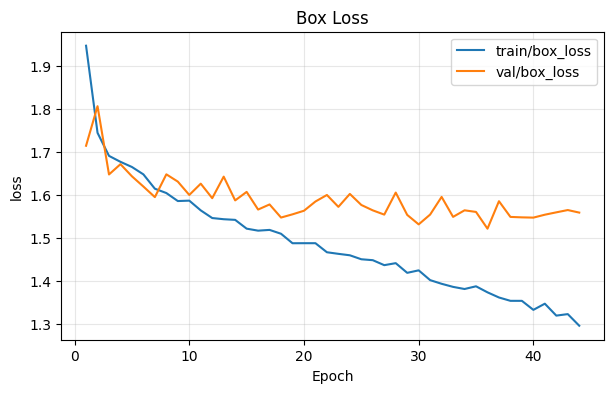

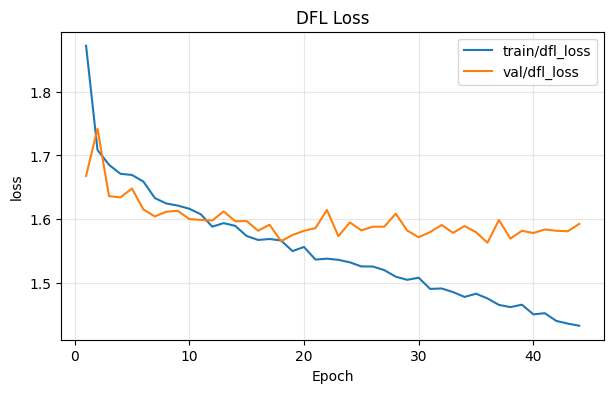

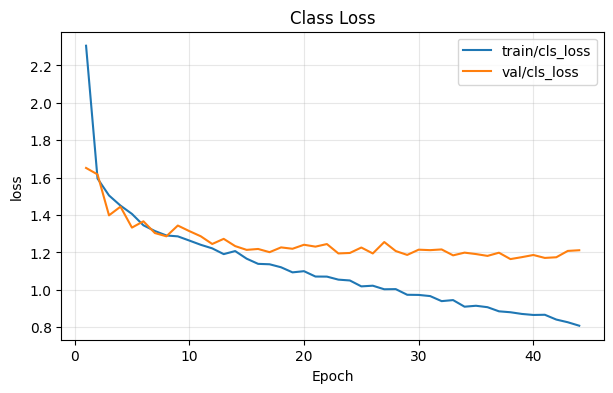

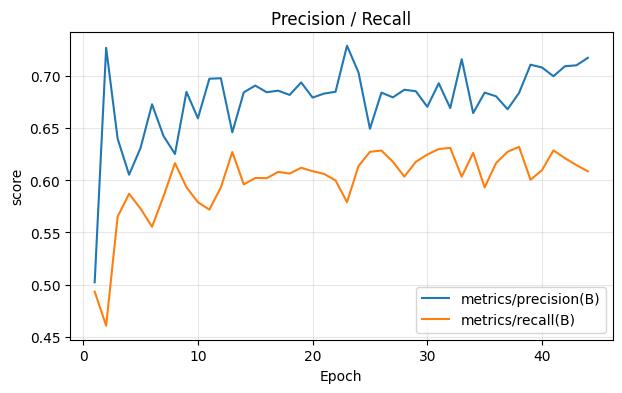

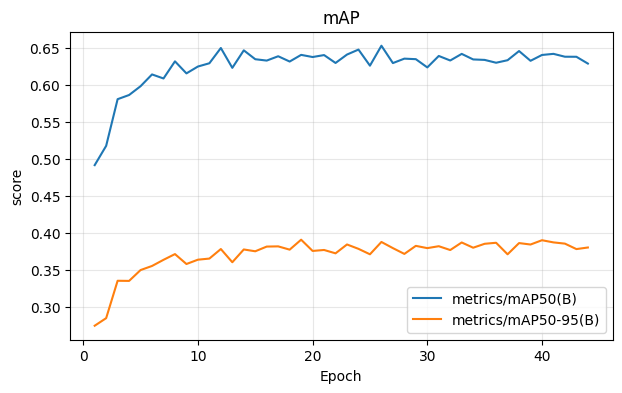

In [40]:
sweep_winner_model, sweep_winner_run_dir, sweep_winner_best_path = train_or_load_yolo(
    sweep_winner_cfg,
    sweep_winner_yaml_path,
)

sweep_winner_val_results, sweep_winner_summary_df = validate_yolo_model(
    sweep_winner_model,
    sweep_winner_cfg,
    sweep_winner_yaml_path,
    sweep_winner_run_dir,
    experiment_name="sweep_winner",
)

plot_training_curves(sweep_winner_run_dir)


## Compare built-in YOLO validation metrics

In [42]:
# Just one experiment in this notebook (the sweep winner) — show its metrics
display(sweep_winner_summary_df)


,experiment,run_name,imgsz,conf_for_mAP,nms_iou,max_det,precision,recall,mAP50,mAP50_95
0,baseline,follicle_yolo_class_weighted,1024,0.001,0.7,1000,0.694174,0.611123,0.640158,0.390465
1,enhanced_balanced,follicle_yolo_original_plus_cp_fft_edge_augmented,1024,0.001,0.7,1000,0.687322,0.611976,0.635302,0.389586


Saved comparison to: /content/drive/MyDrive/yolo_follicle/baseline_vs_enhanced_validation_comparison.csv


## Hungarian matching evaluation

This gives as task specific performance of the model. mAP measure the genral peformance of the detection piple end to end. We care about performnace specfic to the follicel detection.

We do post prediction processing using Hungarrian matching to get match one-to-one between prediction and ground truth. Then evalute confusion metrix on the matched predition and ground truth.

In [62]:
def load_gt_from_yolo_label(image_path: str, label_path: str):
    image = Image.open(image_path).convert("RGB")
    W, H = image.size
    boxes = []
    labels = []
    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                labels.append(int(float(parts[0])))
                boxes.append(yolo_to_xyxy(list(map(float, parts[1:])), W, H))
    return np.array(boxes, dtype=np.float32), np.array(labels, dtype=np.int64)


def predict_yolo_xyxy(model, image_path: str, conf=0.001, imgsz=1024, nms_iou=0.70, max_det=1000):
    result = model.predict(
        image_path,
        conf=conf,
        imgsz=imgsz,
        iou=nms_iou,
        max_det=max_det,
        verbose=False,
    )[0]
    if result.boxes is None or len(result.boxes) == 0:
        return (
            np.zeros((0, 4), dtype=np.float32),
            np.zeros((0,), dtype=np.int64),
            np.zeros((0,), dtype=np.float32),
        )
    boxes = result.boxes.xyxy.cpu().numpy().astype(np.float32)
    labels = result.boxes.cls.cpu().numpy().astype(np.int64)
    scores = result.boxes.conf.cpu().numpy().astype(np.float32)
    return boxes, labels, scores


def hungarian_match(pred_boxes, gt_boxes, iou_threshold=0.5):
    """Return matched prediction indices and GT indices using max-IoU Hungarian assignment."""
    if len(pred_boxes) == 0 or len(gt_boxes) == 0:
        return []
    pb = torch.tensor(pred_boxes, dtype=torch.float32)
    gb = torch.tensor(gt_boxes, dtype=torch.float32)
    ious = box_iou(pb, gb).numpy()
    pred_idx, gt_idx = linear_sum_assignment(-ious)
    matches = []
    for p, g in zip(pred_idx, gt_idx):
        if ious[p, g] >= iou_threshold:
            matches.append((p, g, float(ious[p, g])))
    return matches


def evaluate_yolo_hungarian(
    model,
    cfg: Config,
    stems: List[str],
    id2label: Dict[int, str],
    experiment_name: str,
    pred_conf=0.25,
    nms_iou=0.70,
    match_iou_threshold=0.50,
):
    image_dir = os.path.join(cfg.yolo_root, "images", "val")
    label_dir = os.path.join(cfg.yolo_root, "labels", "val")

    total_predictions = 0
    total_gt = 0
    total_matches = 0
    correct_matches = 0
    sum_matched_iou = 0.0
    y_true, y_pred = [], []

    for stem in tqdm(stems, desc=f"Hungarian eval: {experiment_name}"):
        image_path = find_image_path(image_dir, stem)
        label_path = os.path.join(label_dir, stem + ".txt")
        if image_path is None:
            continue

        gt_boxes, gt_labels = load_gt_from_yolo_label(image_path, label_path)
        pred_boxes, pred_labels, pred_scores = predict_yolo_xyxy(
            model,
            image_path,
            conf=pred_conf,
            imgsz=cfg.image_size,
            nms_iou=nms_iou,
            max_det=cfg.max_det,
        )

        total_predictions += len(pred_boxes)
        total_gt += len(gt_boxes)

        matches = hungarian_match(pred_boxes, gt_boxes, iou_threshold=match_iou_threshold)
        total_matches += len(matches)

        for p, g, iou in matches:
            sum_matched_iou += iou
            gt_label = int(gt_labels[g])
            pred_label = int(pred_labels[p])
            y_true.append(gt_label)
            y_pred.append(pred_label)
            if pred_label == gt_label:
                correct_matches += 1

    label_ids = sorted(id2label.keys())
    label_names = [id2label[i] for i in label_ids]
    cm = confusion_matrix(y_true, y_pred, labels=label_ids)
    cm_df = pd.DataFrame(cm, index=[f"true_{n}" for n in label_names], columns=[f"pred_{n}" for n in label_names])

    unmatched_predictions = total_predictions - total_matches
    unmatched_gt = total_gt - total_matches
    wrong_class_matches = total_matches - correct_matches

    tp = correct_matches
    fp = unmatched_predictions + wrong_class_matches
    fn = unmatched_gt + wrong_class_matches

    class_aware_precision = tp / max(tp + fp, 1)
    class_aware_recall = tp / max(tp + fn, 1)
    class_aware_f1 = 2 * class_aware_precision * class_aware_recall / max(class_aware_precision + class_aware_recall, 1e-8)

    localization_precision = total_matches / max(total_predictions, 1)
    localization_recall = total_matches / max(total_gt, 1)
    localization_f1 = 2 * localization_precision * localization_recall / max(localization_precision + localization_recall, 1e-8)

    metrics = {
        "experiment": experiment_name,
        "pred_conf": pred_conf,
        "nms_iou": nms_iou,
        "match_iou_threshold": match_iou_threshold,
        "total_predictions": total_predictions,
        "total_gt": total_gt,
        "total_matches": total_matches,
        "correct_matches": correct_matches,
        "wrong_class_matches": wrong_class_matches,
        "unmatched_predictions": unmatched_predictions,
        "unmatched_gt": unmatched_gt,
        "mean_iou_matched": sum_matched_iou / max(total_matches, 1),
        "matched_accuracy": accuracy_score(y_true, y_pred) if y_true else 0.0,
        "matched_f1_macro": f1_score(y_true, y_pred, labels=label_ids, average="macro", zero_division=0) if y_true else 0.0,
        "matched_f1_micro": f1_score(y_true, y_pred, labels=label_ids, average="micro", zero_division=0) if y_true else 0.0,
        "class_aware_precision": class_aware_precision,
        "class_aware_recall": class_aware_recall,
        "class_aware_f1": class_aware_f1,
        "localization_precision": localization_precision,
        "localization_recall": localization_recall,
        "localization_f1": localization_f1,
        "tp": tp,
        "fp": fp,
        "fn": fn,
    }

    print(f"===== YOLO Hungarian Evaluation: {experiment_name} =====")
    print(json.dumps(metrics, indent=2))
    display(cm_df)
    return metrics, cm_df


## Hungarian evaluation for both models and compare

In [63]:
sweep_winner_hungarian_metrics, sweep_winner_cm_df = evaluate_yolo_hungarian(
    sweep_winner_model,
    sweep_winner_cfg,
    val_files,
    id2label,
    experiment_name="sweep_winner",
    pred_conf=0.25,
    nms_iou=sweep_winner_cfg.val_iou_threshold,
    match_iou_threshold=0.50,

# (enhanced experiment removed - just the sweep winner)
print(sweep_winner_hungarian_metrics)


Hungarian eval: baseline:   0%|          | 0/330 [00:00<?, ?it/s]

===== YOLO Hungarian Evaluation: baseline =====
{
  "experiment": "baseline",
  "pred_conf": 0.25,
  "nms_iou": 0.7,
  "match_iou_threshold": 0.5,
  "total_predictions": 4622,
  "total_gt": 4227,
  "total_matches": 3485,
  "correct_matches": 3185,
  "wrong_class_matches": 300,
  "unmatched_predictions": 1137,
  "unmatched_gt": 742,
  "mean_iou_matched": 0.8116044489519839,
  "matched_accuracy": 0.9139167862266858,
  "matched_f1_macro": 0.8456852919719404,
  "matched_f1_micro": 0.9139167862266858,
  "class_aware_precision": 0.6890956295975768,
  "class_aware_recall": 0.753489472439082,
  "class_aware_f1": 0.7198553508871058,
  "localization_precision": 0.7540025962786673,
  "localization_recall": 0.8244617932339721,
  "localization_f1": 0.787659622556221,
  "tp": 3185,
  "fp": 1437,
  "fn": 1042
}


,pred_premium,pred_single,pred_undersize,pred_abnormal
true_premium,2252,115,30,5
true_single,99,715,14,1
true_undersize,7,3,168,7
true_abnormal,2,5,12,50


Hungarian eval: enhanced_balanced:   0%|          | 0/330 [00:00<?, ?it/s]

===== YOLO Hungarian Evaluation: enhanced_balanced =====
{
  "experiment": "enhanced_balanced",
  "pred_conf": 0.25,
  "nms_iou": 0.7,
  "match_iou_threshold": 0.5,
  "total_predictions": 4622,
  "total_gt": 4227,
  "total_matches": 3516,
  "correct_matches": 3235,
  "wrong_class_matches": 281,
  "unmatched_predictions": 1106,
  "unmatched_gt": 711,
  "mean_iou_matched": 0.8162869422678519,
  "matched_accuracy": 0.9200796359499431,
  "matched_f1_macro": 0.8589501286635226,
  "matched_f1_micro": 0.9200796359499431,
  "class_aware_precision": 0.6999134573777586,
  "class_aware_recall": 0.7653181925715637,
  "class_aware_f1": 0.7311560628319584,
  "localization_precision": 0.76070964950238,
  "localization_recall": 0.8317955997161107,
  "localization_f1": 0.7946660639620297,
  "tp": 3235,
  "fp": 1387,
  "fn": 992
}


,pred_premium,pred_single,pred_undersize,pred_abnormal
true_premium,2286,98,24,2
true_single,102,733,20,0
true_undersize,5,3,158,7
true_abnormal,6,3,11,58


,experiment,pred_conf,nms_iou,match_iou_threshold,total_predictions,total_gt,total_matches,correct_matches,wrong_class_matches,unmatched_predictions,...,matched_f1_micro,class_aware_precision,class_aware_recall,class_aware_f1,localization_precision,localization_recall,localization_f1,tp,fp,fn
0,baseline,0.25,0.7,0.5,4622,4227,3485,3185,300,1137,...,0.913917,0.689096,0.753489,0.719855,0.754003,0.824462,0.787660,3185,1437,1042
1,enhanced_balanced,0.25,0.7,0.5,4622,4227,3516,3235,281,1106,...,0.920080,0.699913,0.765318,0.731156,0.760710,0.831796,0.794666,3235,1387,992


Saved Hungarian comparison to: /content/drive/MyDrive/yolo_follicle/baseline_vs_enhanced_hungarian_comparison.csv


## Per-epoch Hungarian evaluation across all saved checkpoints

We saved every epoch's checkpoint (`save_period=1`). Now we run Hungarian matching evaluation on each one and tabulate mean IoU, class-aware precision/recall/F1, and matched accuracy per epoch. This lets us pick the best epoch on any criterion (e.g., max mean IoU, max F1, etc.) rather than just Ultralytics' default fitness.

In [ ]:
import glob

# Locate all epoch checkpoints in the run's weights directory
weights_dir = os.path.join(sweep_winner_run_dir, "weights")
epoch_files = sorted(
    glob.glob(os.path.join(weights_dir, "epoch*.pt")),
    key=lambda p: int(os.path.basename(p).replace("epoch", "").replace(".pt", ""))
)
# Also include best.pt and last.pt for completeness
best_pt = os.path.join(weights_dir, "best.pt")
last_pt = os.path.join(weights_dir, "last.pt")

all_checkpoints = epoch_files + ([best_pt] if os.path.exists(best_pt) else []) + ([last_pt] if os.path.exists(last_pt) else [])
print(f"Found {len(all_checkpoints)} checkpoints to evaluate")
for f in all_checkpoints[:5]:
    print("  ", os.path.basename(f))
if len(all_checkpoints) > 5:
    print(f"  ... and {len(all_checkpoints) - 5} more")

# Get the validation stems we evaluate on (subset to keep this fast — 50 imgs is enough)
val_stems = read_split_txt(os.path.join(common_cfg.split_dir, "val.txt"))
eval_stems = val_stems[:50]  # use first 50 val images for speed; set to val_stems for full eval
print(f"\nEvaluating on {len(eval_stems)} val images per checkpoint")

id2label_swp = {i: n for i, n in enumerate(sweep_winner_cfg.class_names)}

per_epoch_rows = []
for ckpt_path in all_checkpoints:
    epoch_label = os.path.basename(ckpt_path).replace(".pt", "")
    print(f"\n=== Evaluating {epoch_label} ===")
    model_ep = YOLO(ckpt_path)
    metrics, _ = evaluate_yolo_hungarian(
        model_ep,
        sweep_winner_cfg,
        eval_stems,
        id2label_swp,
        experiment_name=epoch_label,
        pred_conf=0.25,
        nms_iou=0.70,
        match_iou_threshold=0.50,
    )
    row = {"checkpoint": epoch_label}
    row.update(metrics)
    per_epoch_rows.append(row)

per_epoch_df = pd.DataFrame(per_epoch_rows)
per_epoch_df.to_csv(os.path.join(sweep_winner_run_dir, "per_epoch_hungarian.csv"), index=False)
display(per_epoch_df)


In [ ]:
# Find best epoch by each metric and report
print("=== Best checkpoint by metric ===\n")
metric_cols = [c for c in per_epoch_df.columns if c != "checkpoint" and per_epoch_df[c].dtype in ("float64", "int64")]
for col in metric_cols:
    if "loss" in col.lower():
        idx = per_epoch_df[col].idxmin()
        direction = "min"
    else:
        idx = per_epoch_df[col].idxmax()
        direction = "max"
    print(f"  {col} ({direction}): {per_epoch_df.loc[idx, 'checkpoint']} = {per_epoch_df.loc[idx, col]:.4f}")

# Plot trajectory of key metrics
epoch_only_df = per_epoch_df[per_epoch_df['checkpoint'].str.startswith('epoch')].copy()
epoch_only_df['epoch'] = epoch_only_df['checkpoint'].str.replace('epoch', '').astype(int)
epoch_only_df = epoch_only_df.sort_values('epoch')

plot_metrics = [c for c in ["mean_matched_iou", "matched_accuracy", "precision", "recall", "f1"] if c in epoch_only_df.columns]
if plot_metrics:
    n = len(plot_metrics)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1: axes = [axes]
    for ax, m in zip(axes, plot_metrics):
        ax.plot(epoch_only_df['epoch'], epoch_only_df[m], marker='o')
        ax.set_xlabel('epoch'); ax.set_ylabel(m); ax.set_title(m); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()


#Prediction preview for both models

In [45]:
def show_prediction_preview(model, cfg: Config, n: int = 4, pred_conf_for_display: float = 0.25):
    val_img_paths = list(Path(cfg.yolo_root, "images/val").glob("*.jpg"))[:n]
    for img_path in val_img_paths:
        results = model.predict(
            str(img_path),
            imgsz=cfg.image_size,
            conf=pred_conf_for_display,
            iou=cfg.val_iou_threshold,
            max_det=cfg.max_det,
            verbose=False,
        )
        annotated = results[0].plot()
        annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(7, 7))
        plt.imshow(annotated)
        plt.title(f"{cfg.run_name}: {img_path.name} | display conf={pred_conf_for_display}")
        plt.axis('off')
        plt.show()

show_prediction_preview(sweep_winner_model, sweep_winner_cfg, n=4, pred_conf_for_display=0.25)
show_prediction_preview(sweep_winner_model, sweep_winner_cfg, n=4, pred_conf_for_display=0.25)


Output hidden; open in https://colab.research.google.com to view.